In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('/grid/klindt/home/klindt/MachInterp')
import mis
import odd_one_out
import cross_mis
import metric

sys.path.append('/grid/klindt/home/klindt/VisPopCode')
import activation_paths
from activation_paths import loadData

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
import wandb
import os



# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
save_dir = '/grid/klindt/data/Neuro/vinken2023/dataverse_files/data/'

images = loadmat(os.path.join(save_dir, 'images.mat'))
inputs = images['imarray'].copy()
inputs = np.transpose(inputs, (3, 2, 0, 1))
neural = loadmat(os.path.join(save_dir, 'neural.mat'))
activations = neural['R'].copy().T

dataset = torch.tensor(activations, dtype=torch.float32, device=device)
dataset -= torch.mean(dataset)
dataset /= torch.std(dataset)

num_data, num_neuron = activations.shape

inputs.shape, activations.shape

((1379, 3, 224, 224), (1379, 449))

In [3]:
class SAE(torch.nn.Module):
    def __init__(self, num_input=1024, num_latent=2048):
        super().__init__()
        self.encoder = torch.nn.Linear(num_input, num_latent, bias=True)
        self.decoder = torch.nn.Linear(num_latent, num_input, bias=True)
        
    def forward(self, x):
        z = torch.relu(self.encoder(x))
        rec = self.decoder(z)
        return z, rec
    
sae = SAE(449, 449).to(device)
        
files = os.listdir('/grid/klindt/home/klindt/VisPopCode/results/ckpts/Vinken2023_IT/')
ind_sort = np.argsort([float(_.split('_')[1]) for _ in files])
files = [files[i] for i in ind_sort]

# Take pretty sparse SAE that scored high
f = files[15]
print(f)
PATH = '/grid/klindt/home/klindt/VisPopCode/results/ckpts/Vinken2023_IT/%s/best_latent.pt' % f
z_sae = torch.load(PATH).numpy()
z_sae.shape

lambda_8.8587e+00


(1379, 449)

In [4]:
from sklearn.cluster import MiniBatchKMeans

# fit on the whole data
kmeans = MiniBatchKMeans(
    n_clusters=activations.shape[1],
    random_state=42,
    #batch_size=256,
    #max_iter=10,
    #n_init="auto"
).fit(activations)

z_k = -kmeans.transform(activations)
z_k.shape

(1379, 449)

In [5]:
# Xmis takes a while, so just do the first 10 neurons for demo
codes = {
    'neurons': activations[:, :10],
    'sae': z_sae[:, :10],
    'k-means': z_k[:, :10],
}

In [6]:
# load precomputed similarity_matrix
dreamsim = metric.PrecomputedMetric(
    np.load(os.path.join(save_dir, 'dreamsim_precomputed.npy'))
)

In [7]:
# MIS
result_mis = {}
for key, code in codes.items():
    print('computing', key)
    result_mis[key] = mis.compute_score(
        inputs=inputs,
        activations=code,
        metrics={'dreamsim': dreamsim},
    )

for k, v in result_mis[key].items():
    print(k, v.shape)

computing neurons


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 10.99it/s]


computing sae


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 19.17it/s]


computing k-means


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 16.51it/s]

quantiles (6,)
logits_dreamsim (10, 6, 50, 2, 2)
accuracy_dreamsim (10, 6)


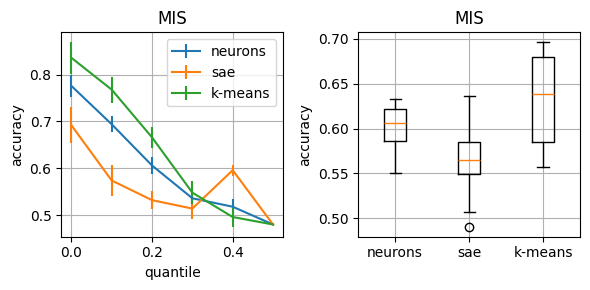

In [8]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
for key, result in result_mis.items():
    plt.errorbar(
        result['quantiles'],
        result['accuracy_dreamsim'].mean(0),
        result['accuracy_dreamsim'].std(0) / np.sqrt(result['accuracy_dreamsim'].shape[0]),
        label=key,
    )
plt.legend()
plt.grid()
plt.xlabel('quantile')
plt.ylabel('accuracy')
plt.title('MIS')

plt.subplot(1, 2, 2)
plt.boxplot(
    [result['accuracy_dreamsim'].mean(1) for result in result_mis.values()]
)
plt.xticks(
    np.arange(1, len(codes) + 1),
    list(codes.keys())
)
plt.grid()
plt.ylabel('accuracy')
plt.title('MIS')
plt.tight_layout()
plt.show()

In [9]:
# Odd one out
result_ooo = {}
for key, code in codes.items():
    print('computing', key)
    result_ooo[key] = odd_one_out.compute_score(
        inputs=inputs,
        activations=code,
        metrics={'dreamsim': dreamsim},
    )

for k, v in result_ooo[key].items():
    print(k, v.shape)

computing neurons


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 217.61it/s]


computing sae


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 253.78it/s]


computing k-means


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 519.15it/s]

ks (5,)
accuracy_dreamsim (10, 5)


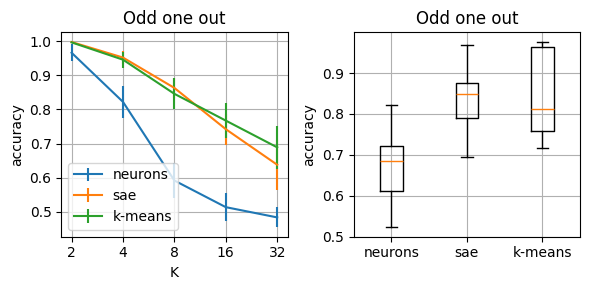

In [10]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
for key, result in result_ooo.items():
    plt.errorbar(
        np.log2(result['ks']),
        result['accuracy_dreamsim'].mean(0),
        result['accuracy_dreamsim'].std(0) / np.sqrt(result['accuracy_dreamsim'].shape[0]),
        label=key,
    )
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('accuracy')
plt.title('Odd one out')
plt.xticks(np.log2(result['ks']), result['ks'])

plt.subplot(1, 2, 2)
plt.boxplot(
    [result['accuracy_dreamsim'].mean(1) for result in result_ooo.values()]
)
plt.xticks(
    np.arange(1, len(codes) + 1),
    list(codes.keys())
)
plt.grid()
plt.ylabel('accuracy')
plt.title('Odd one out')
plt.tight_layout()
plt.show()

In [11]:
# Cross MIS
result_cross = {}
for key, code in codes.items():
    print('computing', key)
    result_cross[key] = cross_mis.compute_score(
        inputs=inputs,
        activations=code,
        metrics={'dreamsim': dreamsim},
    )

for k, v in result_cross[key].items():
    print(k, v.shape)

computing neurons


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 14.95it/s]


computing sae


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 14.99it/s]


computing k-means


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 17.13it/s]

accuracy_dreamsim (10, 10, 9)
ks (9,)


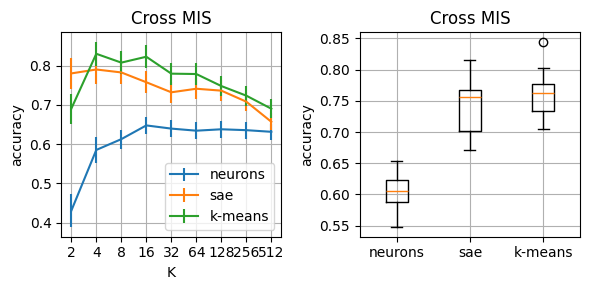

In [12]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
for key, result in result_cross.items():
    plt.errorbar(
        np.log2(result['ks']),
        result['accuracy_dreamsim'].mean((0, 1)),
        result['accuracy_dreamsim'].std((0, 1)) / result['accuracy_dreamsim'].shape[0],
        label=key,
    )
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('accuracy')
plt.title('Cross MIS')
plt.xticks(np.log2(result['ks']), result['ks'])

plt.subplot(1, 2, 2)
plt.boxplot(
    [result['accuracy_dreamsim'].mean((1, 2)) for result in result_cross.values()]
)
plt.xticks(
    np.arange(1, len(codes) + 1),
    list(codes.keys())
)
plt.grid()
plt.ylabel('accuracy')
plt.title('Cross MIS')
plt.tight_layout()
plt.show()

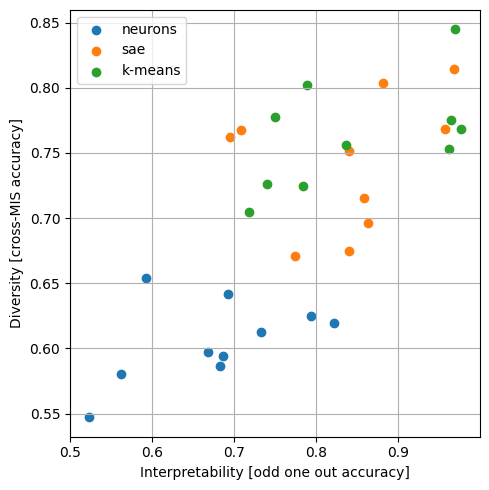

In [13]:
plt.figure(figsize=(5, 5))
for key in codes:
    plt.scatter(
        result_ooo[key]['accuracy_dreamsim'].mean(1)[:10],
        result_cross[key]['accuracy_dreamsim'].mean((1, 2)),
        label=key
    )
plt.legend()
plt.xlabel('Interpretability [odd one out accuracy]')
plt.ylabel('Diversity [cross-MIS accuracy]')
plt.grid()
plt.tight_layout()
plt.show()